#  Обратное распространение ошибки

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* http://cs231n.stanford.edu/handouts/linear-backprop.pdf
* https://www.adityaagrawal.net/blog/deep_learning/bprop_fc
* https://en.wikipedia.org/wiki/Stochastic_gradient_descent

In [2]:
import torch as th


In [3]:
# Библиотеки
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch as th
from torch import Tensor

## Задачи для совместного разбора

1\. Реализуйте обратное распространение ошибки для модели нейрона с квадратичной функцией потерь при условии, что на вход нейрону поступает вектор `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

In [4]:
class ManualNeuron: # Нейрон ручками с обратным распространением
    def __init__(self, input_size, learning_rate=0.01):
        self.weights = torch.randn(input_size, requires_grad=False)
        self.bias = torch.randn(1, requires_grad=False)
        self.learning_rate = learning_rate

    def forward(self, inputs): # Прямой проход: y = w*x + b
        self.inputs = inputs.clone()
        self.output = torch.dot(self.weights, self.inputs) + self.bias
        return self.output

    def backward(self, target): # Обратное распространение для квадратичной функции потерь
        # L = 0.5*(y - ŷ)^2
        self.error = self.output - target
        # Градиенты
        self.dL_dw = self.error * self.inputs  # ∂L/∂w = (y - ŷ) * x
        self.dL_db = self.error                # ∂L/∂b = (y - ŷ)
        self.dL_dx = self.error * self.weights # ∂L/∂x = (y - ŷ) * w
        return self.dL_dx

    def update_parameters(self): # Градиентным спуском апдейтим параметры
        self.weights -= self.learning_rate * self.dL_dw
        self.bias -= self.learning_rate * self.dL_db

In [5]:
class TorchNeuron(nn.Module): # Нейрон с автоматическим дифференцированием PyTorch
    def __init__(self, input_size):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(input_size))
        self.bias = nn.Parameter(torch.randn(1))

    def forward(self, inputs):
        return torch.dot(self.weights, inputs) + self.bias

In [6]:
def quadratic_loss(output, target): # Квадратичная функция потерь
    return 0.5 * (output - target) ** 2

In [7]:
def test_():
    size = 3
    inputs = torch.randn(size)
    target = torch.randn(1)

    manual_neuron = ManualNeuron(size, learning_rate=0.01)
    torch_neuron = TorchNeuron(size)

    with torch.no_grad():
        torch_neuron.weights.data = manual_neuron.weights.clone()
        torch_neuron.bias.data = manual_neuron.bias.clone()

    manual_output = manual_neuron.forward(inputs)
    torch_output = torch_neuron(inputs)
    print(inputs)
    print(target.item())
    print(manual_output.item())
    print(torch_output.item())

    manual_loss = quadratic_loss(manual_output, target)
    torch_loss = quadratic_loss(torch_output, target)
    print(manual_loss.item(), torch_loss.item())

    manual_dL_dx = manual_neuron.backward(target) # Обратное распространение
    torch_loss.backward() # Автоматическое дифференцирование

    print("Параметр\tРучной\t\tPyTorch\t\tРазница")
    print("-" * 55)
    # Градиенты весов
    for i in range(size):
        manual_grad = manual_neuron.dL_dw[i].item()
        torch_grad = torch_neuron.weights.grad[i].item()
        diff = abs(manual_grad - torch_grad)
        print(f"w[{i}]\t\t{manual_grad:.6f}\t{torch_grad:.6f}\t{diff:.2e}")

    # Градиент смещения
    manual_bias_grad = manual_neuron.dL_db.item()
    torch_bias_grad = torch_neuron.bias.grad.item()
    diff_bias = abs(manual_bias_grad - torch_bias_grad)
    print(f"bias\t\t{manual_bias_grad:.6f}\t{torch_bias_grad:.6f}\t{diff_bias:.2e}")

    return manual_neuron, torch_neuron

In [8]:
manual_neuron, torch_neuron = test_() # проверка градиентов

tensor([ 0.3757, -2.5485,  1.4125])
0.10678941756486893
8.070534706115723
8.070534706115723
31.71061897277832 31.71061897277832
Параметр	Ручной		PyTorch		Разница
-------------------------------------------------------
w[0]		2.992207	2.992207	0.00e+00
w[1]		-20.295959	-20.295959	0.00e+00
w[2]		11.248965	11.248965	0.00e+00
bias		7.963745	7.963745	0.00e+00


2\. Настройте модель нейрона, используя метод стохастического градиентного спуска и собственную реализацию обратного распространения ошибки.

In [9]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

In [10]:
coef

array([ 5.63754967, 86.47223763, 27.34070719, 41.48195023])

In [11]:
X.size(), y.size()

(torch.Size([100, 4]), torch.Size([100]))

In [12]:
class Linear:
    def __init__(self, n_neurons: int, n_features: int, bias: bool = False) -> None:
        self.weights = th.randn(n_features, n_neurons)
        self.bias = th.randn(n_neurons)

    def forward(self, inputs: Tensor) -> Tensor:
        return inputs.mm(self.weights) + self.bias #  ["batch", "n_features"] * (n_features, n_neurons)


In [13]:
neuron = Linear(1, X.size()[1])

In [14]:
ep= 1000
lr = 0.1
error = []
for i in th.arange(0, ep):
  y_preds = neuron.forward(X)
  e = (y_preds - y.view(100, 1)).pow(2).mean()
  error.append(e.item())
  dedw = (2/X.size()[0])*(y_preds - y.view(100, 1)).T @ X
  dedb = 2 * (y_preds - y.view(-1, 1)).mean()
  neuron.weights -= lr*dedw.T
  neuron.bias -= lr*dedb
  if i % 100 == 0:
      print('epoch:'+str(i.item())+'    error:'+str(e.item()))


epoch:0    error:9478.8408203125
epoch:100    error:4.1072895085036976e-10
epoch:200    error:4.069584114141378e-10
epoch:300    error:4.069584114141378e-10
epoch:400    error:4.069584114141378e-10
epoch:500    error:4.069584114141378e-10
epoch:600    error:4.069584114141378e-10
epoch:700    error:4.069584114141378e-10
epoch:800    error:4.069584114141378e-10
epoch:900    error:4.069584114141378e-10


In [15]:
from matplotlib import pyplot as plt

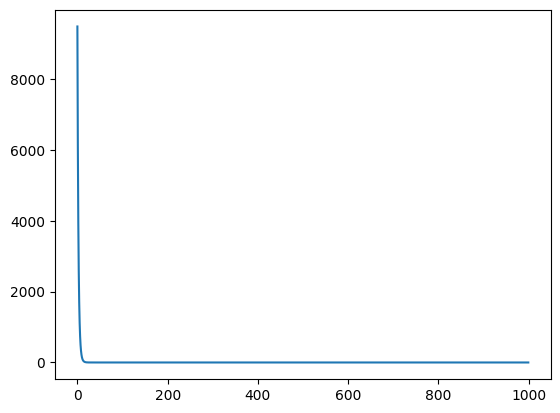

In [16]:
plt.plot(error)

In [17]:
coef

array([ 5.63754967, 86.47223763, 27.34070719, 41.48195023])

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Реализуйте обратное распространение ошибки для модели нейрона с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots \\
w_{m} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$L = \frac{1}{k}\sum_{k}{(\hat{y_k}-y_k)^2}$$

$$\nabla_{\hat{\mathbf{Y}}} L=\begin{bmatrix}
\frac{\partial L}{\partial \hat{y_1}} \\
\frac{\partial L}{\partial \hat{y_2}} \\
\vdots \\
\frac{\partial L}{\partial \hat{y_k}} \\
\end{bmatrix} = \frac{2}{k}\begin{bmatrix}
\hat{y_1} - y_1 \\
\hat{y_2} - y_2 \\
\vdots \\
\hat{y_k} - y_k \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\nabla_{\hat{\mathbf{Y}}} L}$$

- [ ] Проверено на семинаре

In [18]:
class Neuron:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, 1, requires_grad=grad)
        self.dweights = None

    def add_ones_col(self, inputs: Tensor) -> Tensor:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        size = inputs.shape[0]
        ones = th.ones(size, 1, device=inputs.device)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs: Tensor) -> Tensor:
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs: Tensor, dnext: Tensor) -> None:
        inputs_with_bias = self.add_ones_col(inputs)
        self.dweights = inputs_with_bias.t() @ dnext

In [19]:
class MSELoss:
    def forward(self, y_pred: Tensor, y_true: Tensor) -> Tensor:
        self.size = y_pred.shape[0]
        return th.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred: Tensor, y_true: Tensor) -> None:
        self.dinput = (2.0 / self.size) * (y_pred - y_true)

In [20]:
def test_():
    batch_size, n_features = 3, 2
    inputs = th.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], requires_grad=True)
    y_true = th.tensor([[2.0], [4.0], [6.0]])

    neuron = Neuron(n_features, seed=42, grad=True)
    loss_fn = MSELoss()

    # Прямой проход
    y_pred = neuron.forward(inputs)
    loss = loss_fn.forward(y_pred, y_true)

    # Обратный проход
    loss_fn.backward(y_pred, y_true)
    neuron.backward(inputs, loss_fn.dinput)

    # Автоматическое дифференцирование PyTorch
    loss.backward()
    print(neuron.dweights) # Ручками
    print(neuron.weights.grad)

    manual_grad = neuron.dweights
    auto_grad = neuron.weights.grad

    tolerance = 1e-6
    if th.allclose(manual_grad, auto_grad, atol=tolerance):
        print("✓")
    else:
        print("✗")
        print(f"Разница: {th.max(th.abs(manual_grad - auto_grad))}")

if __name__ == "__main__":
    test_()

tensor([[ -4.6781],
        [-17.4301],
        [-22.1081]], grad_fn=<MmBackward0>)
tensor([[ -4.6781],
        [-17.4301],
        [-22.1081]])
✓


<p class="task" id="2"></p>

2\. Настройте модель нейрона, используя метод мини-пакетного градиентного спуска.

Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [21]:
from sklearn.datasets import make_regression
from torch.utils.data import DataLoader, TensorDataset
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [22]:
class Neuron:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, 1, requires_grad=grad)
        self.dweights = None

    def add_ones_col(self, inputs: Tensor) -> Tensor:
        batch_size = inputs.shape[0]
        ones = th.ones(batch_size, 1, device=inputs.device)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs: Tensor) -> Tensor:
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs: Tensor, dnext: Tensor) -> None:
        inputs_with_bias = self.add_ones_col(inputs)
        self.dweights = inputs_with_bias.t() @ dnext

    def update_weights(self, learning_rate: float) -> None:
        with th.no_grad():
            self.weights -= learning_rate * self.dweights

In [23]:
class MSELoss:
    def forward(self, y_pred: Tensor, y_true: Tensor) -> Tensor:
        # MSE: (1/k) * Σ(ŷ_i - y_i)^2
        self.batch_size = y_pred.shape[0]
        return th.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred: Tensor, y_true: Tensor) -> None:
        # градиент: (2/k) * (Ŷ - Y)
        self.dinput = (2.0 / self.batch_size) * (y_pred - y_true)

In [24]:
# Создание DataLoader для мини-пакетов
size = 32
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=size, shuffle=True)

In [25]:
n_features = X.shape[1]
neuron = Neuron(n_features, seed=42)
loss_fn = MSELoss()

In [26]:
learning_rate = 0.01
n_epochs = 100

In [27]:
losses = []
for epoch in range(n_epochs):
    epoch_loss = 0.0
    batch_count = 0

    for batch_X, batch_y in dataloader:
        y_pred = neuron.forward(batch_X)
        loss = loss_fn.forward(y_pred, batch_y)
        loss_fn.backward(y_pred, batch_y)
        neuron.backward(batch_X, loss_fn.dinput)
        neuron.update_weights(learning_rate)

        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count
    losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch + 1}/{n_epochs}, loss: {avg_loss:.6f}")

epoch 20/100, loss: 522.531334
epoch 40/100, loss: 30.261503
epoch 60/100, loss: 2.201216
epoch 80/100, loss: 0.151364
epoch 100/100, loss: 0.012665


In [28]:
trained_weights = neuron.weights.detach().flatten()
bias = trained_weights[0].item()
weights = trained_weights[1:].numpy(); weights, bias

(array([ 5.635304, 86.422325, 27.377048, 41.36824 ], dtype=float32),
 0.5068489909172058)

In [29]:
coef_errors = abs(weights - coef)
bias_error = abs(bias - 0.5); coef_errors, bias_error

(array([0.00224569, 0.04991249, 0.0363413 , 0.11370988]),
 0.0068489909172058105)

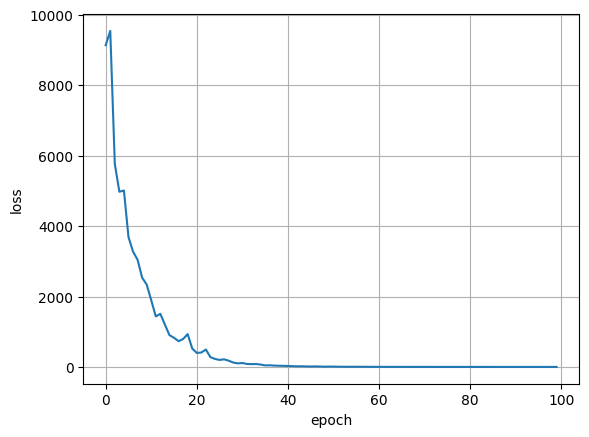

In [30]:
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

<p class="task" id="3"></p>

3\. Реализуйте обратное распространение ошибки для модели полносвязного слоя с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`.  Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

Обратите внимание, что вам потребуются оба градиента $ \boldsymbol{\nabla_{\mathbf{W}} L }$ и $\boldsymbol{\nabla_{\mathbf{X}} L}$ для распространения ошибки с несколькими слоями.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{01} & w_{02} & \ldots & w_{0n} \\
w_{11} & w_{12} & \ldots & w_{1n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \ldots & w_{mn} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$\nabla_{\hat{\mathbf{Y}}} L = \begin{bmatrix}
\frac{\partial L}{\partial \hat{y_{11}}} & \ldots & \frac{\partial L}{\partial \hat{y_{1n}}} \\
\vdots & \vdots & \vdots \\
\frac{\partial L}{\partial \hat{y_{k1}}} & \ldots & \frac{\partial L}{\partial \hat{y_{kn}}} \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\times \nabla_{\hat{\mathbf{Y}}} L}$$
$$\boldsymbol{\nabla_{\mathbf{X}} L = \nabla_{\hat{\mathbf{Y}}} L\times \mathbf{W}^T}$$

- [ ] Проверено на семинаре

In [31]:
import torch as th

class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, n_neurons, requires_grad=grad)
        self.dweights = None
        self.n_features = n_features
        self.n_neurons = n_neurons

    def add_ones_col(self, inputs: Tensor) -> Tensor:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        batch_size = inputs.shape[0]
        ones = th.ones(batch_size, 1, device=inputs.device)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs: Tensor) -> Tensor:
        self.inputs = inputs
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs: Tensor, dnext: Tensor):
        """
        Вычисляет градиенты для весов и возвращает градиент для входов
        dnext: градиент от следующего слоя (batch_size, n_neurons)
        returns: градиент для входов (batch_size, n_features)
        """
        inputs_with_bias = self.add_ones_col(self.inputs)

        self.dweights = inputs_with_bias.t() @ dnext
        weights_without_bias = self.weights[1:, :]
        dinput = dnext @ weights_without_bias.t()

        return dinput


In [32]:
class MSELoss:
    def forward(self, y_pred: Tensor, y_true: Tensor) -> Tensor:
        self.y_pred = y_pred
        self.y_true = y_true
        return th.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred: Tensor, y_true: Tensor) -> Tensor:
        return (2.0 / y_pred.numel()) * (y_pred - y_true)


In [33]:
batch_size, n_features, n_neurons = 3, 2, 2
inputs = th.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]], requires_grad=True)
y_true = th.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

In [34]:
linear = Linear(n_features, n_neurons, seed=42, grad=True)
loss_fn = MSELoss()

In [35]:
y_pred = linear.forward(inputs)
loss = loss_fn.forward(y_pred, y_true)

In [36]:
dloss = loss_fn.backward(y_pred, y_true)
dinput_manual = linear.backward(inputs, dloss)

In [37]:
loss.backward()

In [38]:
print("Градиент весов вручную:")
print(linear.dweights)
print("\nГрадиент весов PyTorch:")
print(linear.weights.grad)
print("\ndW совпадает:", th.allclose(linear.dweights, linear.weights.grad, atol=1e-6))


Градиент весов вручную:
tensor([[ -6.4513,  -3.9255],
        [-24.3898, -14.3258],
        [-30.8411, -18.2513]], grad_fn=<MmBackward0>)

Градиент весов PyTorch:
tensor([[ -6.4513,  -3.9255],
        [-24.3898, -14.3258],
        [-30.8411, -18.2513]])

dW совпадает: True


In [39]:
print("Градиент входов вручную:")
print(dinput_manual)
print("\nГрадиент входов PyTorch:")
print(inputs.grad)
print("\ndX совпадает:", th.allclose(dinput_manual, inputs.grad, atol=1e-6))


Градиент входов вручную:
tensor([[-0.3636,  1.1261],
        [-0.8056,  2.6585],
        [-1.2476,  4.1908]], grad_fn=<MmBackward0>)

Градиент входов PyTorch:
tensor([[-0.3636,  1.1261],
        [-0.8056,  2.6585],
        [-1.2476,  4.1908]])

dX совпадает: True


<p class="task" id="4"></p>

4\. Настройте полносвязный слой, используя метод пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [40]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [41]:
class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, n_neurons, requires_grad=grad)
        self.dweights = None

    def add_ones_col(self, inputs):
        batch_size = inputs.shape[0]
        ones = th.ones(batch_size, 1, device=inputs.device)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs):
        self.inputs = inputs
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs, dnext):
        inputs_with_bias = self.add_ones_col(inputs)
        self.dweights = inputs_with_bias.t() @ dnext

    def update_weights(self, learning_rate: float):
        with th.no_grad():
            self.weights -= learning_rate * self.dweights

In [42]:
class MSELoss:
    def forward(self, y_pred, y_true):
        self.batch_size = y_pred.shape[0]
        return th.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred, y_true):
        self.dinput = (2.0 / self.batch_size) * (y_pred - y_true)
        return self.dinput

In [43]:
n_features = X.shape[1]
n_neurons = 1
linear = Linear(n_features, n_neurons, seed=42)
loss_fn = MSELoss()

In [44]:
# Гиперпараметры
learning_rate = 0.01
n_epochs = 1000
batch_size = X.shape[0]  # Пакетный градиентный спуск (вся выборка)

In [45]:
losses = []
for epoch in range(n_epochs):
    y_pred = linear.forward(X)
    loss = loss_fn.forward(y_pred, y)
    dloss = loss_fn.backward(y_pred, y)
    linear.backward(X, dloss)
    linear.update_weights(learning_rate)
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"epoch {epoch + 1}/{n_epochs}, loss: {loss.item():.6f}")

epoch 100/1000, loss: 228.623306
epoch 200/1000, loss: 7.421139
epoch 300/1000, loss: 0.300308
epoch 400/1000, loss: 0.013480
epoch 500/1000, loss: 0.000633
epoch 600/1000, loss: 0.000030
epoch 700/1000, loss: 0.000002
epoch 800/1000, loss: 0.000000
epoch 900/1000, loss: 0.000000
epoch 1000/1000, loss: 0.000000


In [46]:
trained_weights = linear.weights.detach().flatten()
bias = trained_weights[0].item()
weights = trained_weights[1:].numpy(); weights, bias

(array([ 5.637558, 86.47203 , 27.340784, 41.48182 ], dtype=float32),
 0.5000032186508179)

In [47]:
coef_errors = abs(weights - coef)
bias_error = abs(bias - 0.5); coef_errors, bias_error

(array([8.31830573e-06, 2.06985857e-04, 7.68798054e-05, 1.31080934e-04]),
 3.2186508178710938e-06)

In [48]:
final_pred = linear.forward(X)
final_loss = loss_fn.forward(final_pred, y)
print(f"MSE: {final_loss.item():.6f}")

MSE: 0.000000


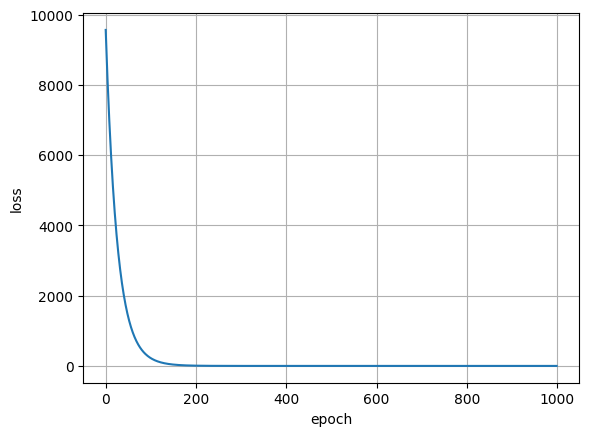

In [49]:
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

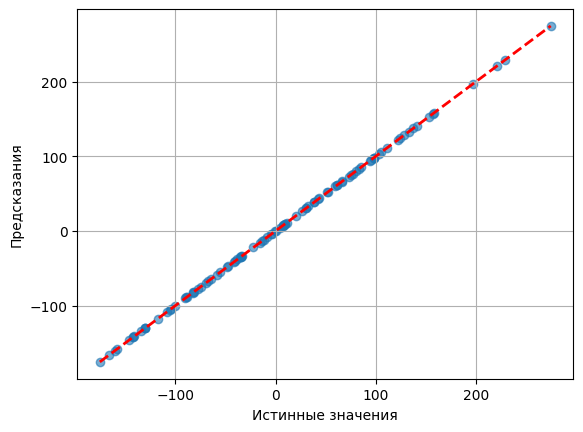

In [50]:
plt.scatter(y.numpy(), final_pred.detach().numpy(), alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказания')
plt.grid(True)

<p class="task" id="5"></p>

5\. Используя решения предыдущих задач, создайте нейросеть и решите задачу регрессии. При наличии корректно реализованных методов `backward` у `Linear` и `MSE` вы можете обобщить процедуру распространения ошибки на любое количество слоев. Реализуйте и обучите модель, состояющую из двух полносвязных слоев:

1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 1 нейроном;

Схематично процедура обратного распространения ошибки представлена на рис. ниже.

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).


- [ ] Проверено на семинаре

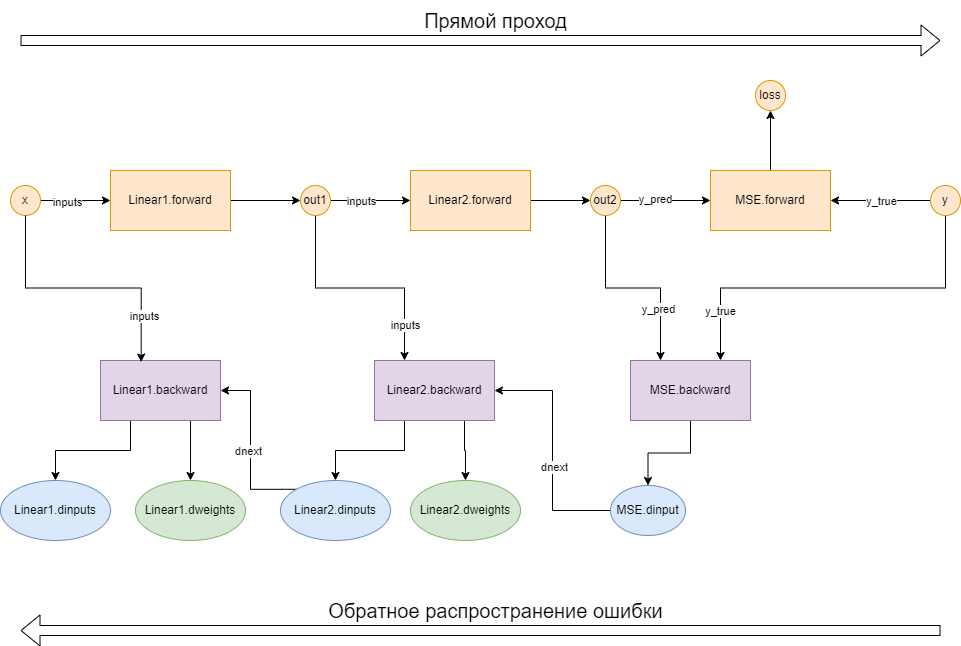

In [51]:
import torch as th

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())


In [52]:
class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, init_scale: float = 0.1):
        if seed is not None:
            th.manual_seed(seed)
        # Первый ряд весов отвечает за bias.
        self.weights = init_scale * th.randn(n_features + 1, n_neurons, requires_grad=False)
        self.dweights = None
        self.inputs = None

    def add_ones_col(self, inputs):
        ones = th.ones(
            inputs.shape[0], 1,
            device=inputs.device,
            dtype=inputs.dtype
        )
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs):
        self.inputs = inputs
        return self.add_ones_col(inputs) @ self.weights

    def backward(self, dnext):
        inputs_with_bias = self.add_ones_col(self.inputs)
        self.dweights = inputs_with_bias.t() @ dnext
        # Bias не является входным признаком, поэтому первый ряд весов исключаем.
        return dnext @ self.weights[1:, :].t()

    def update_weights(self, learning_rate: float):
        with th.no_grad():
            self.weights -= learning_rate * self.dweights


In [53]:
class MSELoss:
    def forward(self, y_pred, y_true):
        return th.mean((y_pred - y_true) ** 2)

    def backward(self, y_pred, y_true):
        return (2.0 / y_pred.numel()) * (y_pred - y_true)


In [54]:
class LinearNeuralNetwork:
    """Два полносвязных слоя БЕЗ функции активации: Linear(1→10) → Linear(10→1)."""
    def __init__(self, input_size=1, hidden_size=10, output_size=1):
        self.linear1 = Linear(input_size, hidden_size, seed=42)
        self.linear2 = Linear(hidden_size, output_size, seed=43)

    def forward(self, x):
        hidden = self.linear1.forward(x)
        return self.linear2.forward(hidden)

    def backward(self, dloss):
        dhidden = self.linear2.backward(dloss)
        return self.linear1.backward(dhidden)

    def update_weights(self, learning_rate):
        self.linear2.update_weights(learning_rate)
        self.linear1.update_weights(learning_rate)


In [55]:
model_linear = LinearNeuralNetwork(input_size=1, hidden_size=10, output_size=1)
loss_fn = MSELoss()


In [56]:
learning_rate = 0.1
n_epochs = 5000
print_interval = 500
epochs_to_save = [0, 100, 500, 1000, 2000, 3000, 4999]


In [57]:
linear_predictions_history = []
linear_losses = []

for epoch in range(n_epochs):
    y_pred = model_linear.forward(X)
    loss = loss_fn.forward(y_pred, y)

    if epoch in epochs_to_save:
        linear_predictions_history.append((epoch, y_pred.detach().clone()))

    dloss = loss_fn.backward(y_pred, y)
    model_linear.backward(dloss)
    model_linear.update_weights(learning_rate)
    linear_losses.append(loss.item())

    if (epoch + 1) % print_interval == 0:
        print(f"Эпоха {epoch + 1}/{n_epochs}, Loss: {loss.item():.6f}")


Эпоха 500/5000, Loss: 0.097589
Эпоха 1000/5000, Loss: 0.097589
Эпоха 1500/5000, Loss: 0.097589
Эпоха 2000/5000, Loss: 0.097589
Эпоха 2500/5000, Loss: 0.097589
Эпоха 3000/5000, Loss: 0.097589
Эпоха 3500/5000, Loss: 0.097589
Эпоха 4000/5000, Loss: 0.097589
Эпоха 4500/5000, Loss: 0.097589
Эпоха 5000/5000, Loss: 0.097589


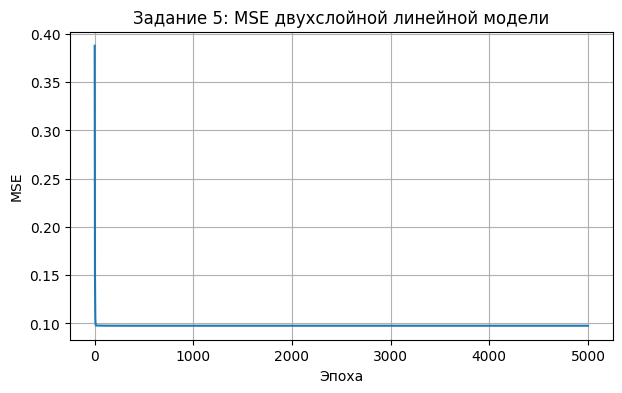

In [58]:
plt.figure(figsize=(7, 4))
plt.plot(linear_losses)
plt.title('Задание 5: MSE двухслойной линейной модели')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.grid(True)
plt.show()


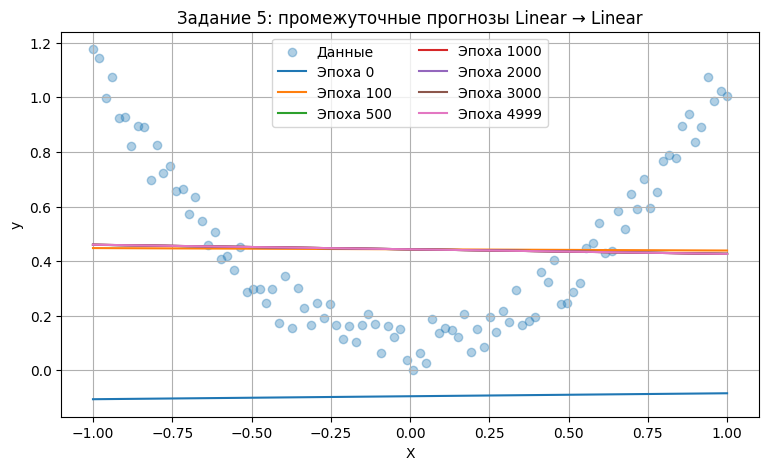

In [59]:
plt.figure(figsize=(9, 5))
plt.scatter(X.numpy(), y.numpy(), alpha=0.35, label='Данные')

for epoch, pred in linear_predictions_history:
    plt.plot(X.numpy(), pred.numpy(), linewidth=1.5, label=f'Эпоха {epoch}')

plt.title('Задание 5: промежуточные прогнозы Linear → Linear')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend(ncol=2)
plt.show()


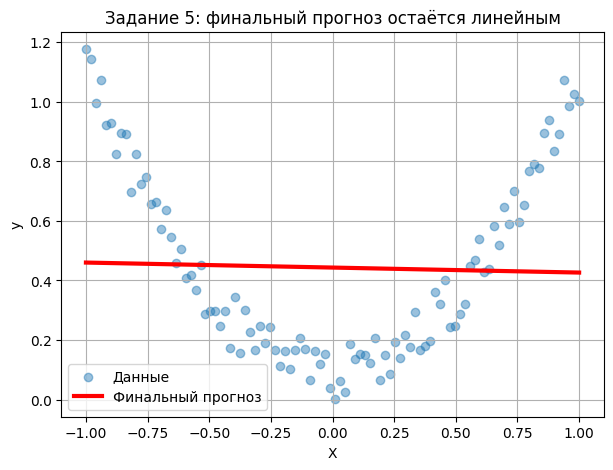

In [60]:
linear_final_pred = model_linear.forward(X).detach()

plt.figure(figsize=(7, 5))
plt.scatter(X.numpy(), y.numpy(), alpha=0.45, label='Данные')
plt.plot(X.numpy(), linear_final_pred.numpy(), 'r-', linewidth=3, label='Финальный прогноз')
plt.title('Задание 5: финальный прогноз остаётся линейным')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()


In [61]:
print(f"Параметров Linear1: {model_linear.linear1.weights.numel()}")
print(f"Параметров Linear2: {model_linear.linear2.weights.numel()}")
print(f"Всего параметров: {model_linear.linear1.weights.numel() + model_linear.linear2.weights.numel()}")
print(f"Финальный MSE: {linear_losses[-1]:.6f}")


Параметров Linear1: 20
Параметров Linear2: 11
Всего параметров: 31
Финальный MSE: 0.097589


In [62]:
A = th.cat([th.ones_like(X), X], dim=1)
solution = th.linalg.lstsq(A, linear_final_pred).solution
linear_fit = A @ solution
max_deviation = th.max(th.abs(linear_fit - linear_final_pred)).item()
print(f"Максимальное отклонение прогноза сети от одной прямой: {max_deviation:.2e}")


Максимальное отклонение прогноза сети от одной прямой: 1.79e-07


<p class="task" id="6"></p>

6\. Модель из предыдущей задачи является линейной и не способна качественно предсказать искомую зависимость. Для того, чтобы сделать модель нелинейной, в нейронных сетях используются функции активации. Для того, чтобы встроить такую функцию в процесс обратного распространения ошибки, необходимо реализовать соответствующий слой с методами `forward` и `backward`.

$$
f(x) = \max(0, x)
$$

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial f}\frac{\partial f}{\partial x} = \frac{\partial L}{\partial f}
\begin{cases}
1 & \text{если } x \ge 0 \\
0 & \text{если } x <  0
\end{cases}
$$

Здесь $L$ - это функция (слой), следующая за ReLU в потоке вычислений.

Реализуйте и обучите модель, состояющую из двух полносвязных слоев, разделенных функцией активации ReLU:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).




- [ ] Проверено на семинаре

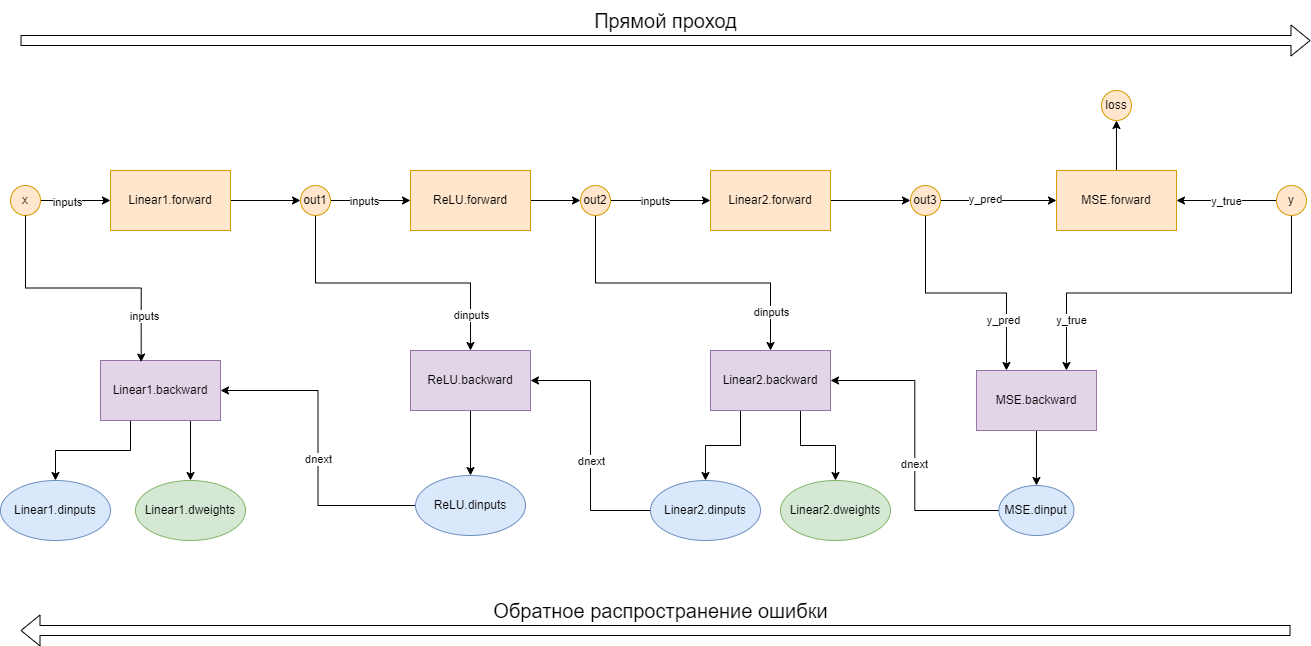

In [66]:
class ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        return th.clamp(inputs, min=0)

    def backward(self, dvalues):
        return dvalues * (self.inputs > 0).float()

In [67]:
th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

In [70]:
class NeuralNetworkWithReLU:
    def __init__(self, input_size, hidden_size, output_size):
        self.linear1 = Linear(input_size, hidden_size, seed=42)
        self.relu = ReLU()
        self.linear2 = Linear(hidden_size, output_size, seed=43)

    def forward(self, x):
        self.hidden_linear = self.linear1.forward(x)
        self.hidden_relu = self.relu.forward(self.hidden_linear)
        return self.linear2.forward(self.hidden_relu)

    def backward(self, dloss):
        dlinear2 = self.linear2.backward(dloss)
        drelu = self.relu.backward(dlinear2)
        return self.linear1.backward(drelu)

    def update_weights(self, learning_rate):
        self.linear2.update_weights(learning_rate)
        self.linear1.update_weights(learning_rate)


Эпоха 500/5000, Loss: 0.010647
Эпоха 1000/5000, Loss: 0.004558
Эпоха 1500/5000, Loss: 0.003767
Эпоха 2000/5000, Loss: 0.003686
Эпоха 2500/5000, Loss: 0.003673
Эпоха 3000/5000, Loss: 0.003668
Эпоха 3500/5000, Loss: 0.003663
Эпоха 4000/5000, Loss: 0.003661
Эпоха 4500/5000, Loss: 0.003659
Эпоха 5000/5000, Loss: 0.003657


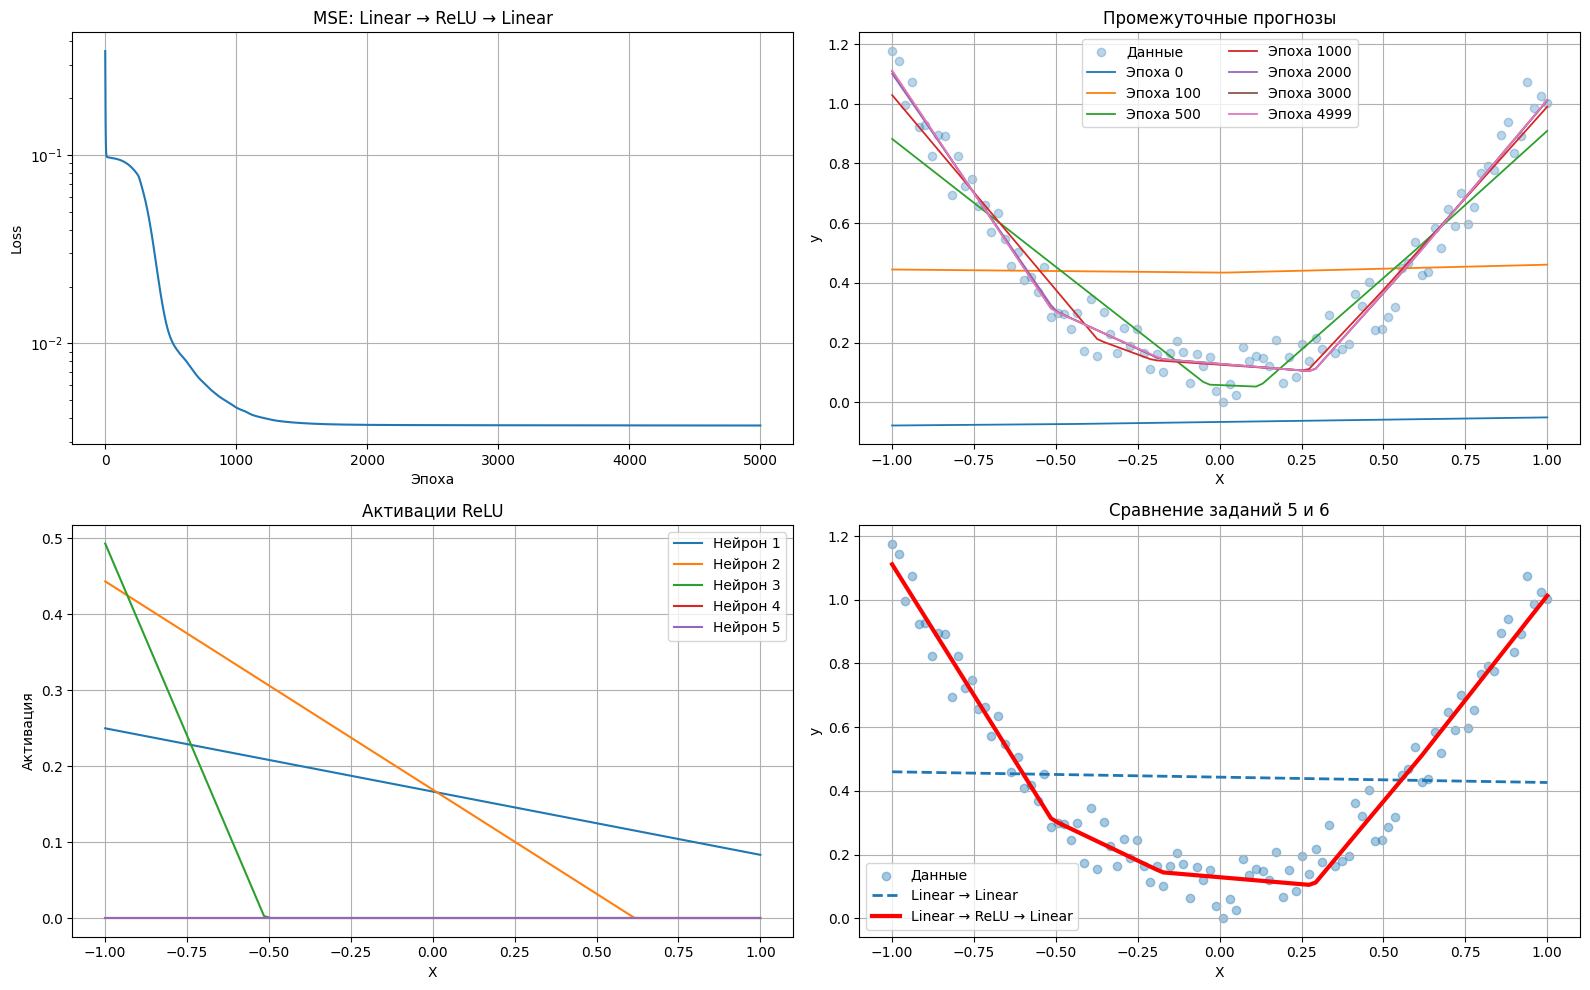

Финальный MSE без ReLU: 0.097589
Финальный MSE с ReLU:  0.003657
Параметров в ReLU-модели: 31


In [71]:
model_relu = NeuralNetworkWithReLU(input_size=1, hidden_size=10, output_size=1)
loss_fn_relu = MSELoss()

learning_rate = 0.1
n_epochs = 5000
print_interval = 500
epochs_to_save = [0, 100, 500, 1000, 2000, 3000, 4999]

relu_predictions_history = []
relu_losses = []

for epoch in range(n_epochs):
    y_pred = model_relu.forward(X)
    loss = loss_fn_relu.forward(y_pred, y)

    if epoch in epochs_to_save:
        relu_predictions_history.append((epoch, y_pred.detach().clone()))

    dloss = loss_fn_relu.backward(y_pred, y)
    model_relu.backward(dloss)
    model_relu.update_weights(learning_rate)
    relu_losses.append(loss.item())

    if (epoch + 1) % print_interval == 0:
        print(f"Эпоха {epoch + 1}/{n_epochs}, Loss: {loss.item():.6f}")

final_relu_pred = model_relu.forward(X).detach()

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(relu_losses)
plt.yscale('log')
plt.title('MSE: Linear → ReLU → Linear')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(X.numpy(), y.numpy(), alpha=0.3, label='Данные')
for epoch, pred in relu_predictions_history:
    plt.plot(X.numpy(), pred.numpy(), linewidth=1.3, label=f'Эпоха {epoch}')
plt.title('Промежуточные прогнозы')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend(ncol=2)

plt.subplot(2, 2, 3)
model_relu.forward(X)
activations = model_relu.hidden_relu.detach().numpy()
for i in range(min(5, activations.shape[1])):
    plt.plot(X.numpy(), activations[:, i], label=f'Нейрон {i+1}')
plt.title('Активации ReLU')
plt.xlabel('X')
plt.ylabel('Активация')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.scatter(X.numpy(), y.numpy(), alpha=0.4, label='Данные')
plt.plot(X.numpy(), linear_final_pred.numpy(), '--', linewidth=2, label='Linear → Linear')
plt.plot(X.numpy(), final_relu_pred.numpy(), 'r-', linewidth=3, label='Linear → ReLU → Linear')
plt.title('Сравнение заданий 5 и 6')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальный MSE без ReLU: {linear_losses[-1]:.6f}")
print(f"Финальный MSE с ReLU:  {relu_losses[-1]:.6f}")
print(f"Параметров в ReLU-модели: {model_relu.linear1.weights.numel() + model_relu.linear2.weights.numel()}")


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ